In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc

In [86]:
df = pd.read_csv("../cwt_data/cwt_supervised.csv")

In [87]:
df.head()

,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,...,pkt_phase,src_mean,src_phase,dst_mean,dst_phase,byte_mean,byte_phase,thr_mean,thr_phase,Label
0,4,0,0,0,0,0,0,0,0,0,...,0.233364,0.000000,3.141593,0.000000,3.141593,15.100750,-0.956510,60402.998858,-0.956510,0
1,87,0,0,0,0,0,14,196,33,0,...,0.233364,17.581824,0.051762,25.194885,0.049700,238.311096,-1.028469,3258.921129,-1.028469,0
2,4,0,0,0,0,0,0,0,0,0,...,0.233364,0.000000,3.141593,0.000000,3.141593,13.727221,-0.979326,54908.885109,-0.979326,0
3,20,0,6,0,6,0,88,999,264,0,...,-0.027926,85.793764,0.017670,87.906681,0.021966,974.560326,-1.251845,6767.786108,-1.251847,0
4,6,2,0,0,0,0,6,19,8,0,...,0.075951,1.311885,0.052357,1.591377,0.038745,48.699588,-0.204543,10529.588968,-0.204542,0


In [88]:
df['Label'].value_counts()

Label
1    33424
0    30000
Name: count, dtype: int64

In [89]:
df_features = df.drop(columns=["Attack"])

In [90]:
df_features.shape

(63424, 28)

In [91]:
df_features.columns

Index(['NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
       'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
       'NUM_PKTS_1024_TO_1514_BYTES', 'SRC_TO_DST_IAT_MIN',
       'SRC_TO_DST_IAT_AVG', 'SRC_TO_DST_IAT_MAX', 'SRC_TO_DST_IAT_STDDEV',
       'DST_TO_SRC_IAT_MIN', 'DST_TO_SRC_IAT_AVG', 'DST_TO_SRC_IAT_MAX',
       'DST_TO_SRC_IAT_STDDEV', 'IN_BYTES', 'OUT_BYTES',
       'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'pkt_mean',
       'pkt_phase', 'src_mean', 'src_phase', 'dst_mean', 'dst_phase',
       'byte_mean', 'byte_phase', 'thr_mean', 'thr_phase', 'Label'],
      dtype='object')

In [92]:
X = df_features.drop(columns=['Label'])

In [93]:
y = df_features['Label']

In [94]:
print(X.shape)
print(y.shape)

(63424, 27)
(63424,)


In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [96]:
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (50739, 27)
Test size: (12685, 27)


In [97]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

In [98]:
trained_models = {}

In [ ]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

In [ ]:
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    }

results_df = pd.DataFrame(results).T
print(results_df)

                     Accuracy        F1    Recall
Logistic Regression  0.956799  0.959918  0.974747
KNN                  0.992984  0.993396  0.994355
Random Forest        0.998818  0.998887  0.999554


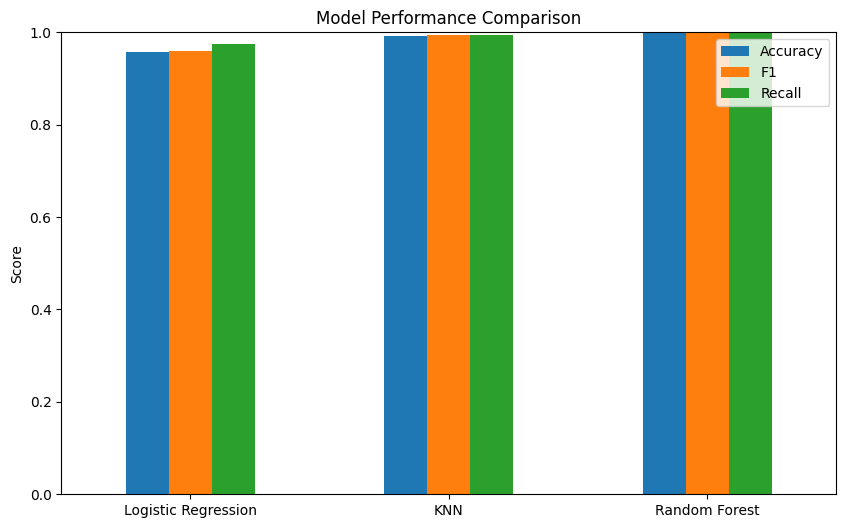

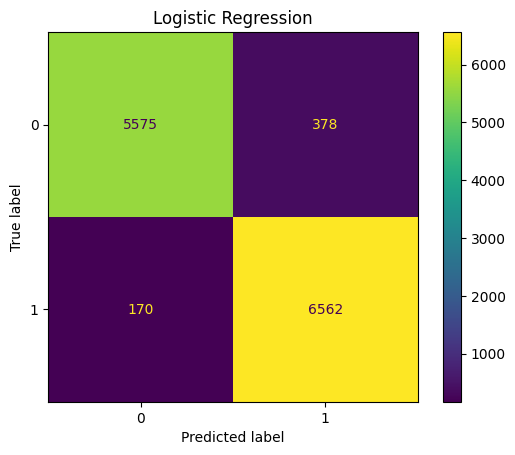

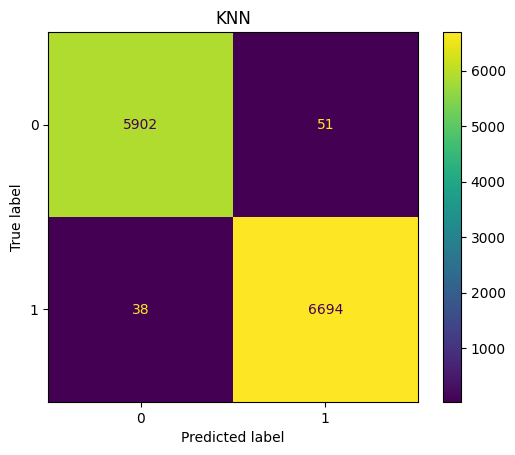

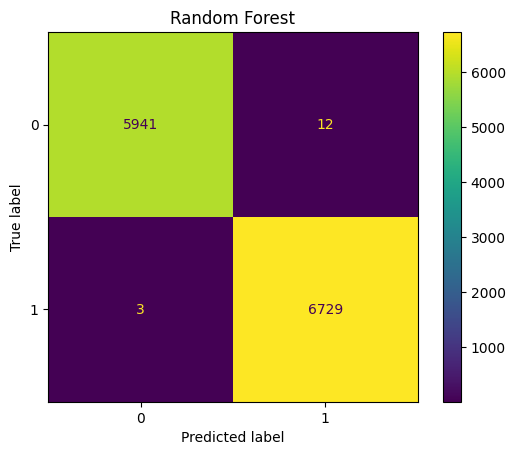

In [105]:
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(name)
    plt.show()